<a href="https://colab.research.google.com/github/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/blob/main/notebooks/01_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Airfoil Noise — Data Exploration**

### Engineering Question
How accurately can the sound pressure level generated by a NACA 0012 airfoil be predicted from its operating and geometric parameters using linear regression and decision tree regression?

### Purpose
This notebook explores the Airfoil Self-Noise dataset before model development. The dataset contains experimental aerodynamic and acoustic measurements from tests of NACA 0012 airfoil sections.

# **Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Column names provided by the UCI Airfoil Self-Noise dataset
column_names = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level"
]

# Raw GitHub URL for the dataset
data_url = "https://raw.githubusercontent.com/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/refs/heads/main/data/airfoil_self_noise.dat"

df = pd.read_csv(
    data_url,
    sep="\t",
    names=column_names
)

## Dataset Variables

The model uses five input variables to predict airfoil sound pressure level.

| Variable | Description | Unit | Role |
|---|---|---|---|
| Frequency | Sound frequency | Hz | Input |
| Angle of attack | Airfoil angle of attack | degrees | Input |
| Chord length | Airfoil chord length | m | Input |
| Free-stream velocity | Air velocity | m/s | Input |
| Displacement thickness | Suction-side displacement thickness | m | Input |
| Sound pressure level | Scaled sound pressure level | dB | Output |

# **Data Inspection**

In [21]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.head()

Number of rows: 1503
Number of columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   frequency               1503 non-null   int64  
 1   angle_of_attack         1503 non-null   float64
 2   chord_length            1503 non-null   float64
 3   free_stream_velocity    1503 non-null   float64
 4   displacement_thickness  1503 non-null   float64
 5   sound_pressure_level    1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


,frequency,angle_of_attack,chord_length,free_stream_velocity,displacement_thickness,sound_pressure_level
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


# **Data Quality**

In [8]:
df.isnull().sum()

,0
frequency,0
angle_of_attack,0
chord_length,0
free_stream_velocity,0
displacement_thickness,0
sound_pressure_level,0


# **Descriptive Statistics**

In [9]:
df.describe()

,frequency,angle_of_attack,chord_length,free_stream_velocity,displacement_thickness,sound_pressure_level
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000




Descriptive statistics are used to examine the range and distribution of the
input and output variables. This also establishes the domain over which the
subsequent prediction models will be developed and evaluated.

# **Exploring the variables visually**

The relationships between each input variable and sound pressure level are examined visually. This helps identify trends, nonlinear behaviour, outliers, and other characteristics that may influence the choice of prediction model.

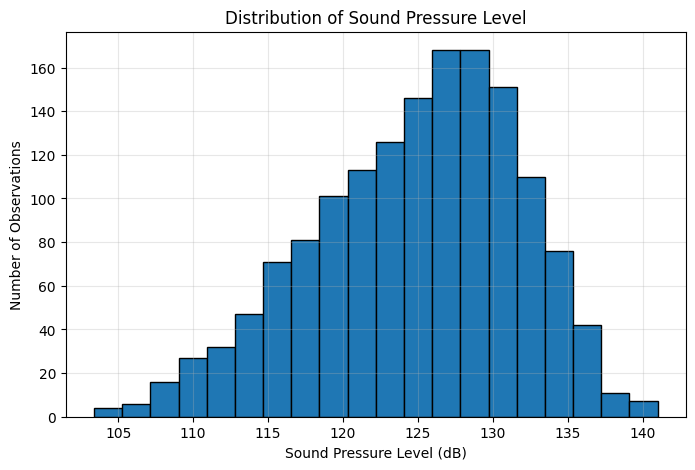

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["sound_pressure_level"], bins=20, edgecolor="black")

plt.xlabel("Sound Pressure Level (dB)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Sound Pressure Level")
plt.grid(alpha=0.3)

plt.show()

The sound pressure level ranges from approximately 103.4 dB to 141.0 dB. The distribution is concentrated around approximately 125–130 dB, with fewer observations occurring at the lower and upper extremes.

The output variable therefore covers a reasonably broad range of sound pressure levels, providing data across different noise conditions

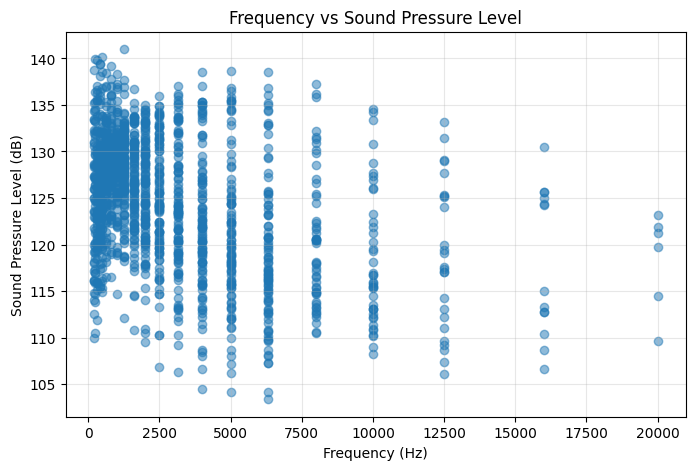

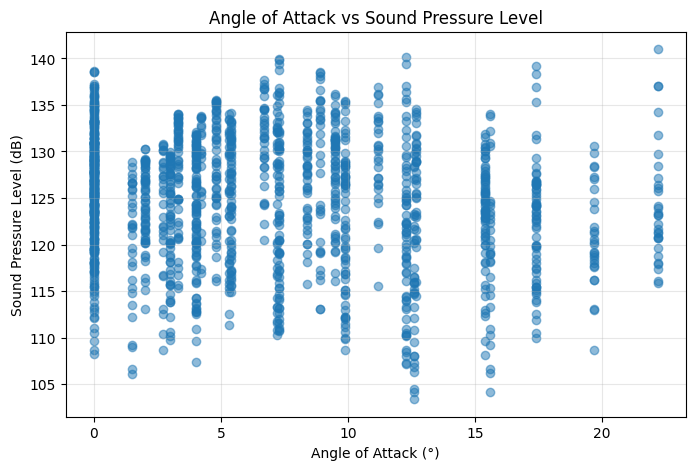

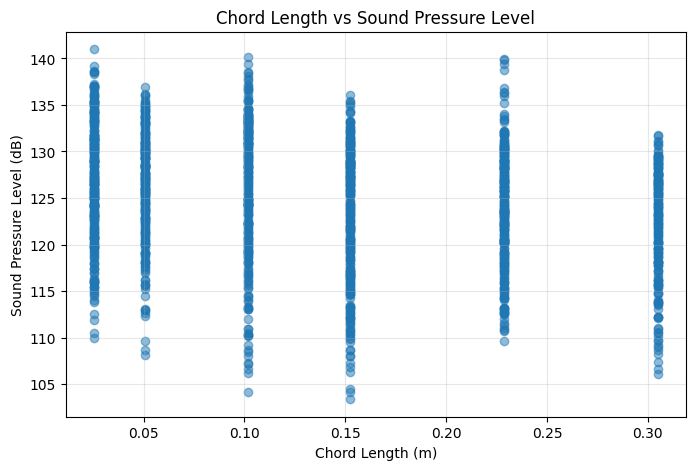

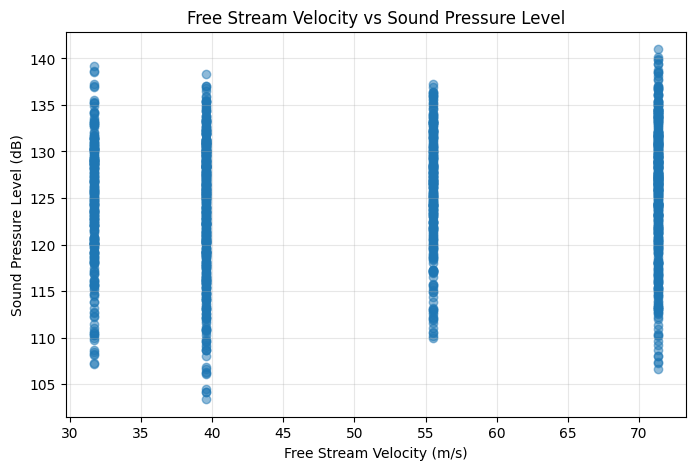

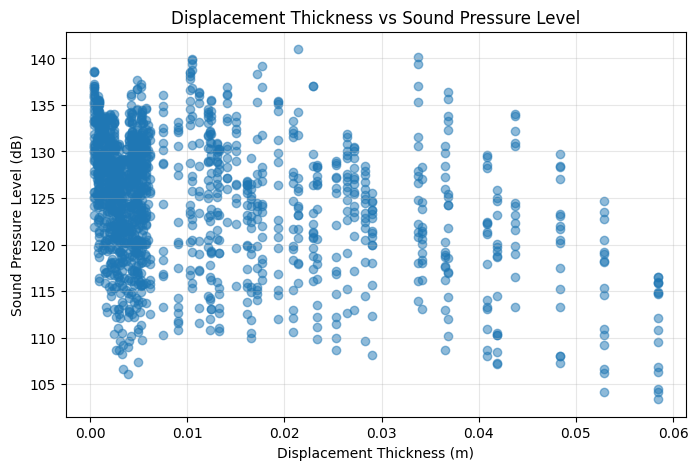

In [17]:
# Input variables with display names and engineering units
input_variables = {
    "frequency": ("Frequency", "Hz"),
    "angle_of_attack": ("Angle of Attack", "°"),
    "chord_length": ("Chord Length", "m"),
    "free_stream_velocity": ("Free Stream Velocity", "m/s"),
    "displacement_thickness": ("Displacement Thickness", "m")
}

# Plot each input variable against sound pressure level
for variable, (name, unit) in input_variables.items():
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df[variable],
        df["sound_pressure_level"],
        alpha=0.5
    )

    plt.xlabel(f"{name} ({unit})")
    plt.ylabel("Sound Pressure Level (dB)")
    plt.title(f"{name} vs Sound Pressure Level")
    plt.grid(alpha=0.3)

    plt.show()

## Analysis of Graphs

### Frequency
The frequency data range from 200 Hz to 20,000 Hz. The scatter plot suggests an overall tendency for sound pressure level to decrease as frequency increases. However, substantial variation in sound pressure level occurs at the same or similar frequencies.

This indicates that frequency alone does not determine the sound pressure level and that the relationship is influenced by the other operating and geometric parameters.

### Angle of Attack

No clear linear relationship between angle of attack and sound pressure level is apparent from the scatter plot. A wide range of sound pressure levels occurs at several angles of attack, indicating that the effect of angle of attack cannot be considered independently of the other variables.


### Chord Length

The dataset contains measurements at a limited number of discrete chord lengths rather than continuously varying chord dimensions. Sound pressure level varies substantially within each chord length.

However, the large spread within each chord length shows that chord length alone is insufficient to explain the measured noise.

### Free-Stream Velocity

The scatter plot shows substantial variation in sound pressure level at each free-stream velocity, with no clear linear trend. The measurements were taken at four discrete velocities rather than across a continuous range.

### Displacement Thickness

The scatter plot indicates a general tendency for higher displacement thickness to be associated with lower sound pressure levels. However, substantial scatter is present, particularly at lower displacement thicknesses.


# **Correlation**

Correlation coefficients are calculated to quantify the strength and direction
of the linear relationships between the variables. This complements the visual
analysis and assists in assessing whether a linear regression model is a
reasonable baseline.

In [13]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix
spl_correlation = correlation_matrix["sound_pressure_level"].sort_values(
    ascending=False
)

spl_correlation

,sound_pressure_level
sound_pressure_level,1.000000
free_stream_velocity,0.125103
angle_of_attack,-0.156108
chord_length,-0.236162
displacement_thickness,-0.312670
frequency,-0.390711


### Correlation Results

Frequency has the largest absolute linear correlation with sound pressure level (r ≈ -0.39), followed by displacement thickness (r ≈ -0.31). Chord length and angle of attack show weaker negative correlations, while free-stream velocity has a weak positive correlation (r ≈ 0.13).

None of the individual input variables has a strong linear correlation with sound pressure level. This suggests that sound pressure level cannot be explained adequately by considering individual variables independently.

Additionally, correlation measures linear association and doesn't indicate causation. Weak individual correlations also do not imply that a parameter is unimportant when considered together with the other variables.

# **Findings**


The Airfoil Self Noise dataset contains 1,503 observations with five input variables and one output variable. No missing values were identified. The measured sound pressure level ranges from approximately 103.4 dB to 141.0 dB.

Visual exploration showed variation in sound pressure level across all five variables. Frequency and displacement thickness exhibited the clearest negative associations with sound pressure level, while chord length and angle of attack showed weaker negative associations. Free stream velocity showed only a weak positive linear association.

The correlation analysis supports these observations. Frequency had the largest absolute correlation with sound pressure level (r ≈ -0.39), followed by displacement thickness (r ≈ -0.31). No individual input showed a strong linear correlation with the output.

The scatter plots also show considerable variation in sound pressure level at similar values of individual inputs. This indicates that predicting airfoil noise is a multivariable problem and that the relationship between the inputs
and sound pressure level may not be adequately represented by simple individual linear relationships.

**Based on these findings, multiple linear regression will be investigated as a simple and interpretable baseline model using all five input variables. A decision tree regression model will then be evaluated as an alternative capable of representing nonlinear relationships and interactions between the input
variables. The models will be compared using withheld test data  and prediction error metrics.**